<a href="https://colab.research.google.com/github/Simran0606/BCG_JobSimulation/blob/main/BCG_Exploratory_Data_Analysis_and_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 2. Load datasets

In [2]:


customer_df = pd.read_csv("/content/client_data (1).csv")
price_df = pd.read_csv("/content/price_data (1).csv")


print("Customer data shape:", customer_df.shape)
print("Price data shape:", price_df.shape)


Customer data shape: (14606, 26)
Price data shape: (193002, 8)


# 3. Preview datasets

In [4]:

print("Customer data")
display(customer_df.head())

print("Price data")
display(price_df.head())



Customer data


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


Price data


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


# 4. Check column names

In [5]:

print("Customer columns:")
print(customer_df.columns.tolist())

print("\nPrice columns:")
print(price_df.columns.tolist())



Customer columns:
['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'date_activ', 'date_end', 'date_modif_prod', 'date_renewal', 'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy', 'forecast_meter_rent_12m', 'forecast_price_energy_off_peak', 'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas', 'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act', 'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn']

Price columns:
['id', 'price_date', 'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']


# 5. Data types of each column

### Data types
We first reviewed the data types of each column to distinguish numeric, categorical and date fields. This helps determine the appropriate summary statistics and visualisations for each variable.

In [6]:

print("Customer data types:")
display(customer_df.dtypes.reset_index().rename(columns={"index": "column", 0: "dtype"}))

print("Price data types:")
display(price_df.dtypes.reset_index().rename(columns={"index": "column", 0: "dtype"}))



Customer data types:


,column,dtype
0,id,object
1,channel_sales,object
2,cons_12m,int64
3,cons_gas_12m,int64
4,cons_last_month,int64
5,date_activ,object
6,date_end,object
7,date_modif_prod,object
8,date_renewal,object
9,forecast_cons_12m,float64


Price data types:


,column,dtype
0,id,object
1,price_date,object
2,price_off_peak_var,float64
3,price_peak_var,float64
4,price_mid_peak_var,float64
5,price_off_peak_fix,float64
6,price_peak_fix,float64
7,price_mid_peak_fix,float64


# 6. Basic summary information

In [7]:

def dataset_summary(df, name):
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("\nMissing values:")
    display(df.isnull().sum().sort_values(ascending=False))
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nDescriptive statistics (numeric):")
    display(df.describe())
    print("\nDescriptive statistics (categorical):")
    display(df.describe(include="object"))

dataset_summary(customer_df, "Customer Data")
dataset_summary(price_df, "Price Data")

===== Customer Data =====
Shape: (14606, 26)

Missing values:


,0
id,0
channel_sales,0
cons_12m,0
cons_gas_12m,0
cons_last_month,0
date_activ,0
date_end,0
date_modif_prod,0
date_renewal,0
forecast_cons_12m,0



Duplicate rows: 0

Descriptive statistics (numeric):


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000



Descriptive statistics (categorical):


...

,0
id,0
price_date,0
price_off_peak_var,0
price_peak_var,0
price_mid_peak_var,0
price_off_peak_fix,0
price_peak_fix,0
price_mid_peak_fix,0



Duplicate rows: 0

Descriptive statistics (numeric):


,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221



Descriptive statistics (categorical):


,id,price_date
count,193002,193002
unique,16096,12
top,c18b6305122e4976739b8420d5b54ec5,2015-12-01
freq,12,16094


# 7. Convert date columns if present

In [8]:


date_cols_customer = ["date_activ", "date_end", "date_modif_prod", "date_renewal"]
date_cols_price = ["price_date"]
date_cols_churn = []

for col in date_cols_customer:
    if col in customer_df.columns:
        customer_df[col] = pd.to_datetime(customer_df[col], errors="coerce")

for col in date_cols_price:
    if col in price_df.columns:
        price_df[col] = pd.to_datetime(price_df[col], errors="coerce")


print("Date conversion complete.")

Date conversion complete.


# 8. Separate numeric and categorical columns

In [10]:

def get_column_types(df):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    datetime_cols = df.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
    return numeric_cols, categorical_cols, datetime_cols

cust_num, cust_cat, cust_date = get_column_types(customer_df)
price_num, price_cat, price_date_cols = get_column_types(price_df)


print("Customer numeric columns:", cust_num)
print("Customer categorical columns:", cust_cat)
print("Customer datetime columns:", cust_date)

print("\nPrice numeric columns:", price_num)
print("Price categorical columns:", price_cat)
print("Price datetime columns:", price_date_cols)



Customer numeric columns: ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy', 'forecast_meter_rent_12m', 'forecast_price_energy_off_peak', 'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act', 'net_margin', 'num_years_antig', 'pow_max', 'churn']
Customer categorical columns: ['id', 'channel_sales', 'has_gas', 'origin_up']
Customer datetime columns: ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

Price numeric columns: ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']
Price categorical columns: ['id']
Price datetime columns: ['price_date']


# 9. Plot distributions for numeric columns

### Distribution analysis
We examined numeric distributions using histograms and boxplots to detect skewness and outliers. Categorical variables were analysed using countplots to understand the spread of customer groups and product types.

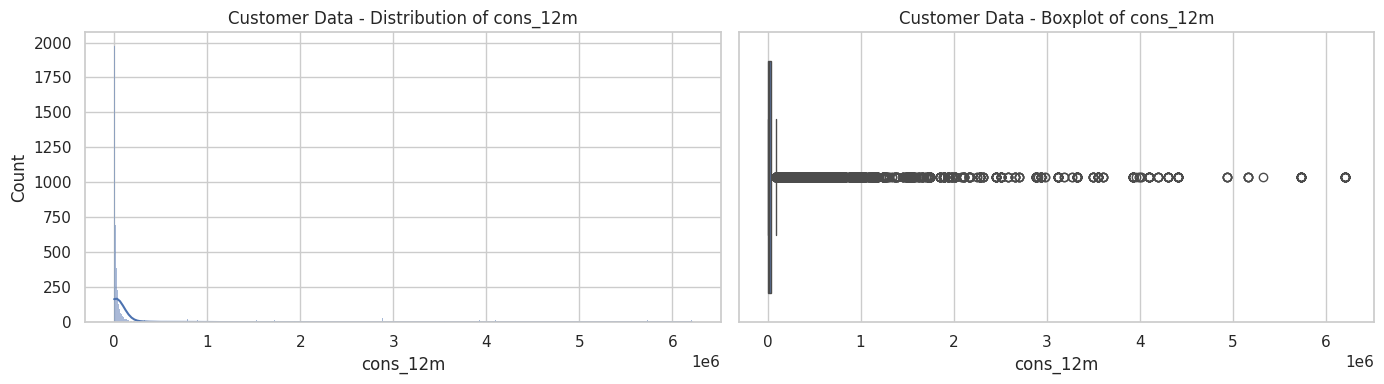

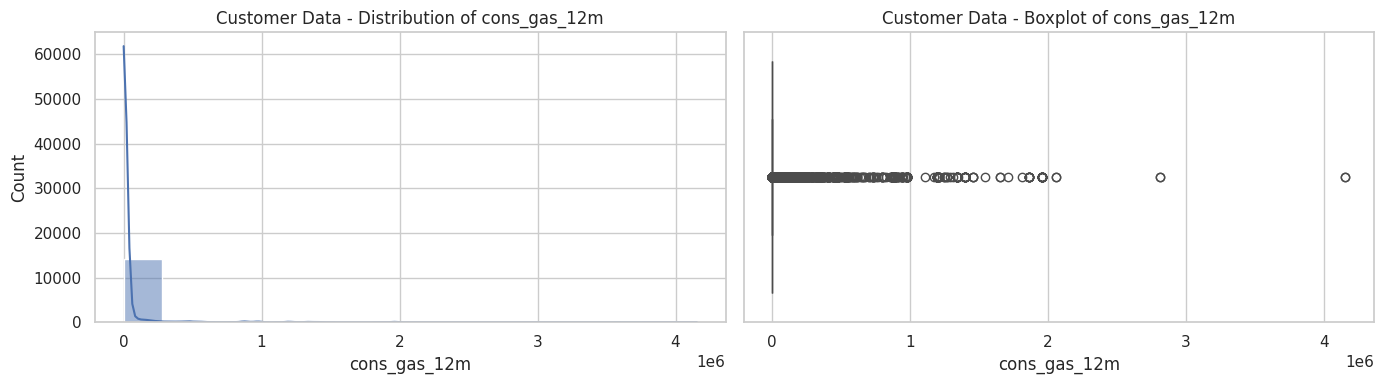

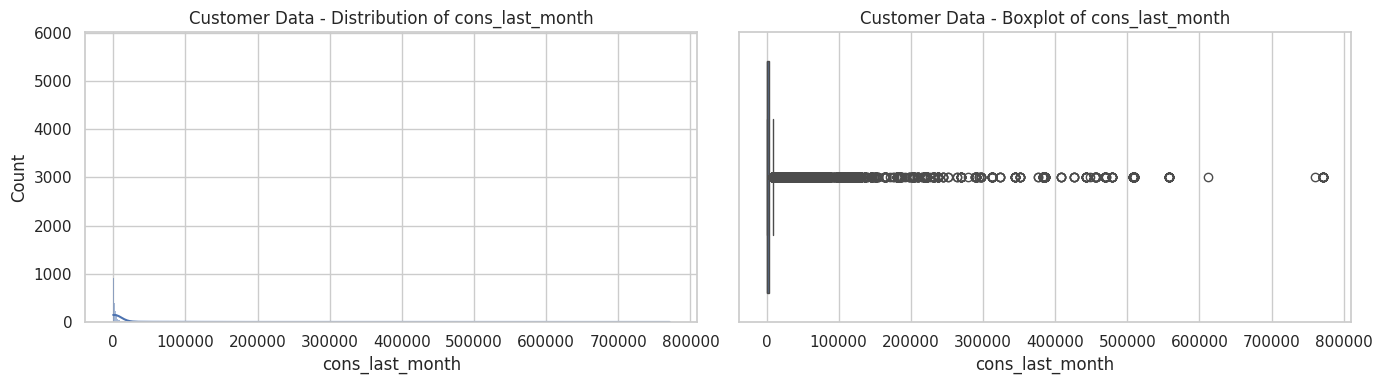

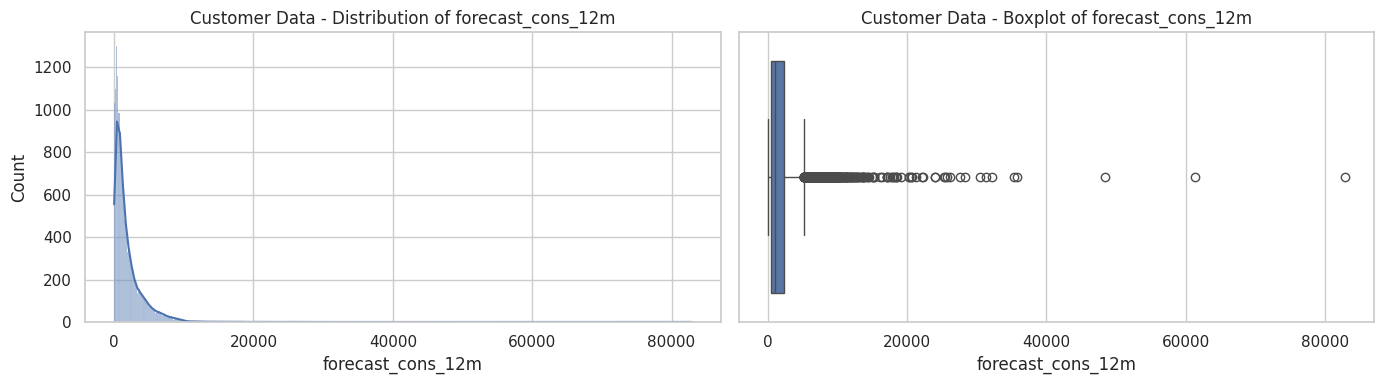

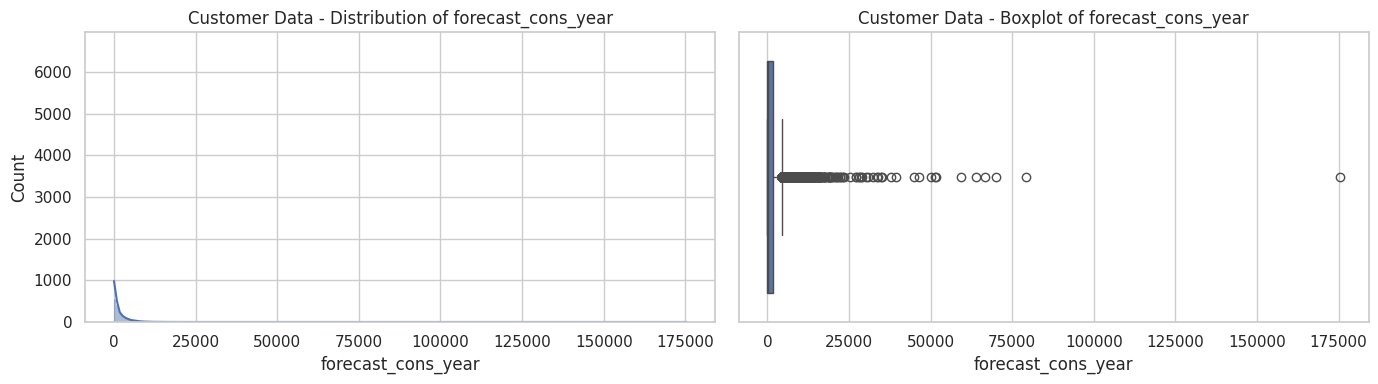

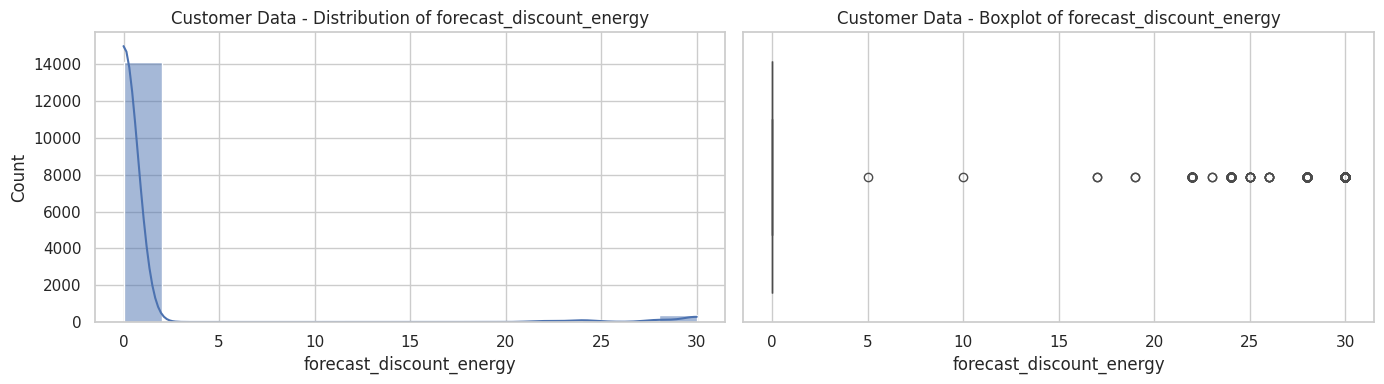

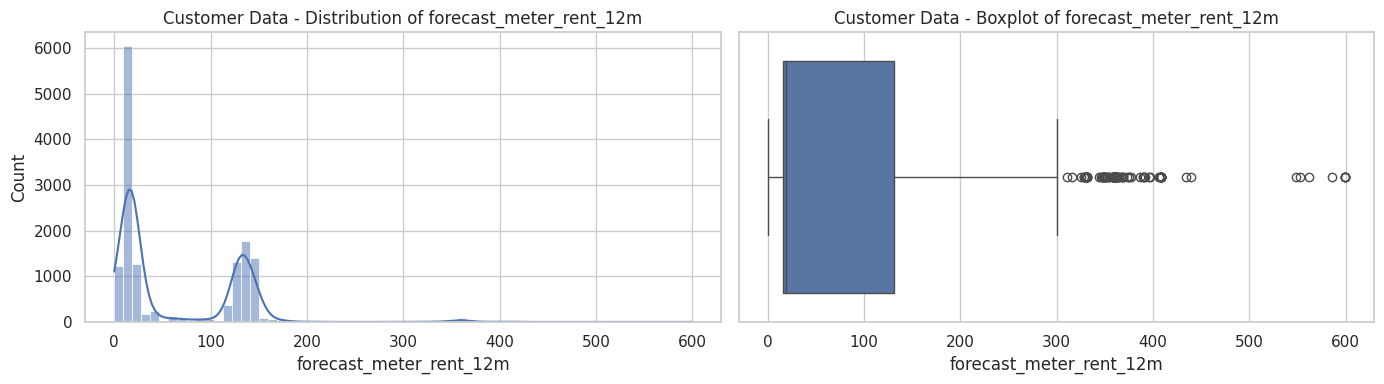

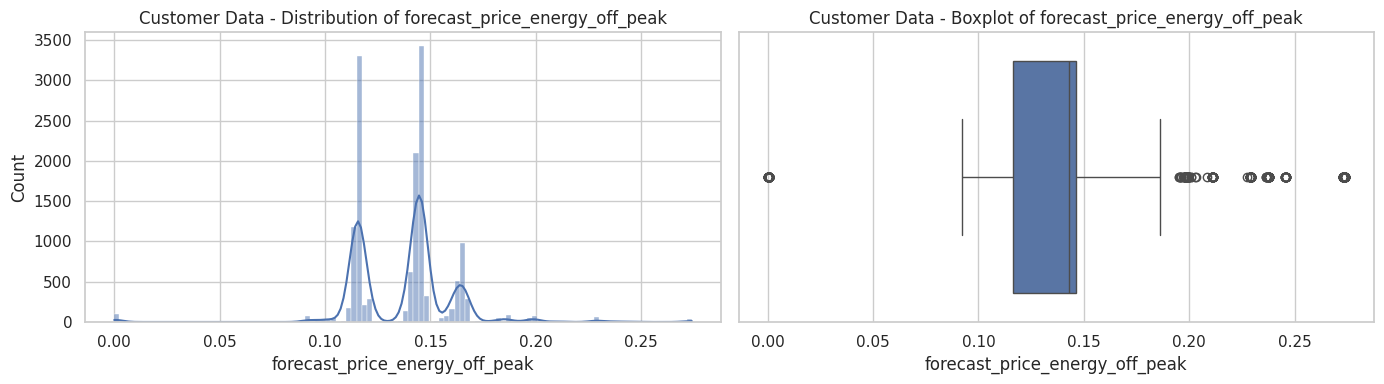

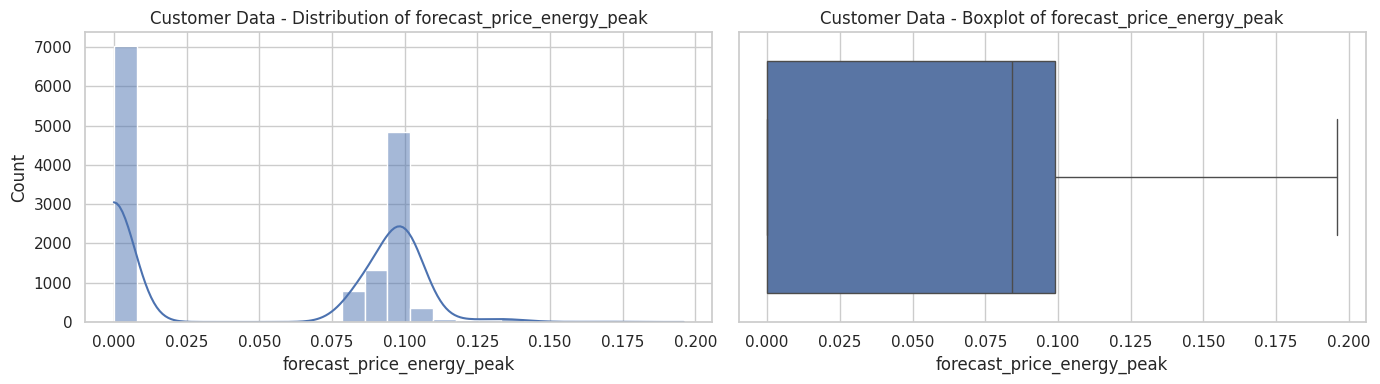

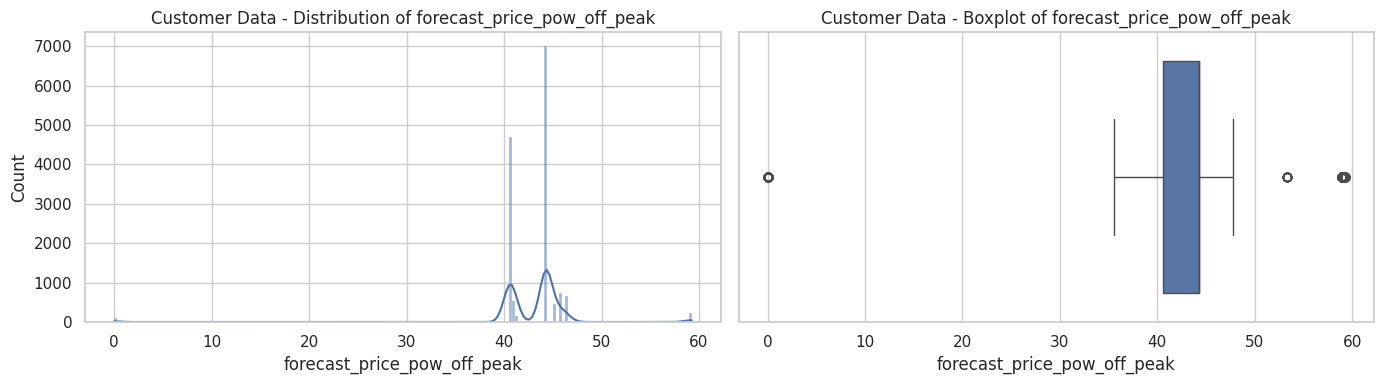

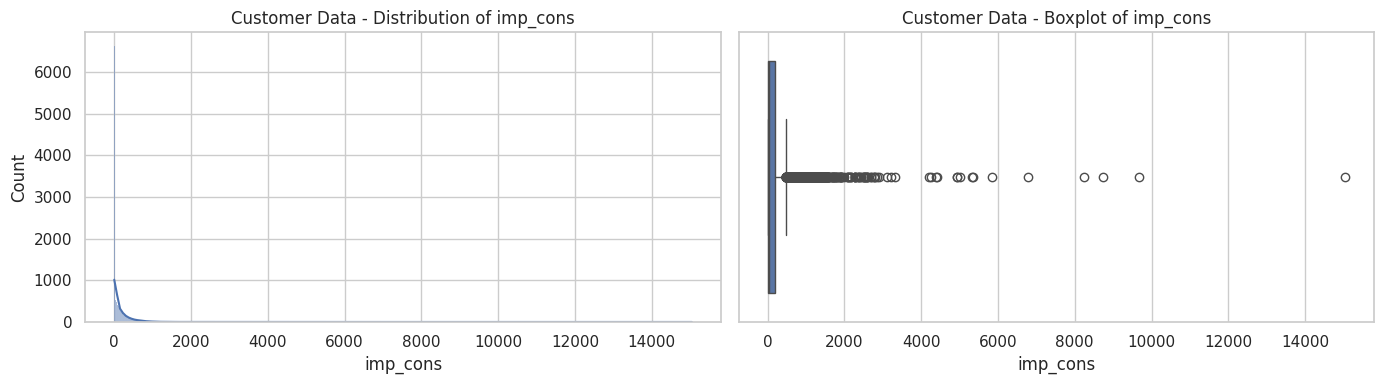

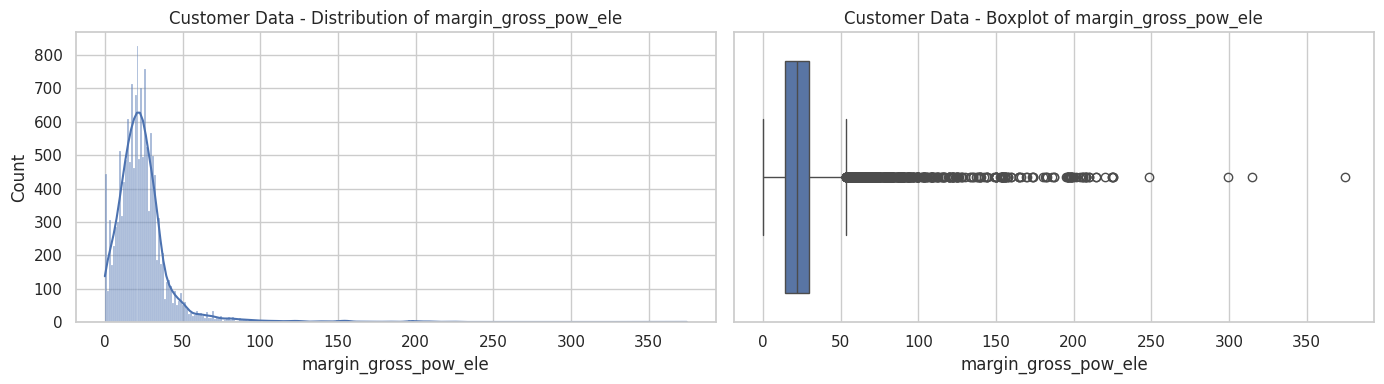

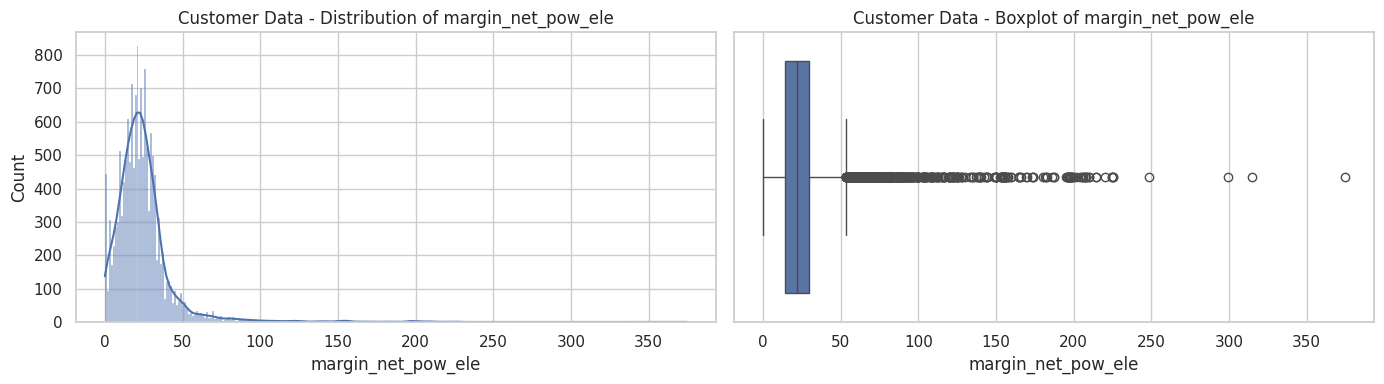

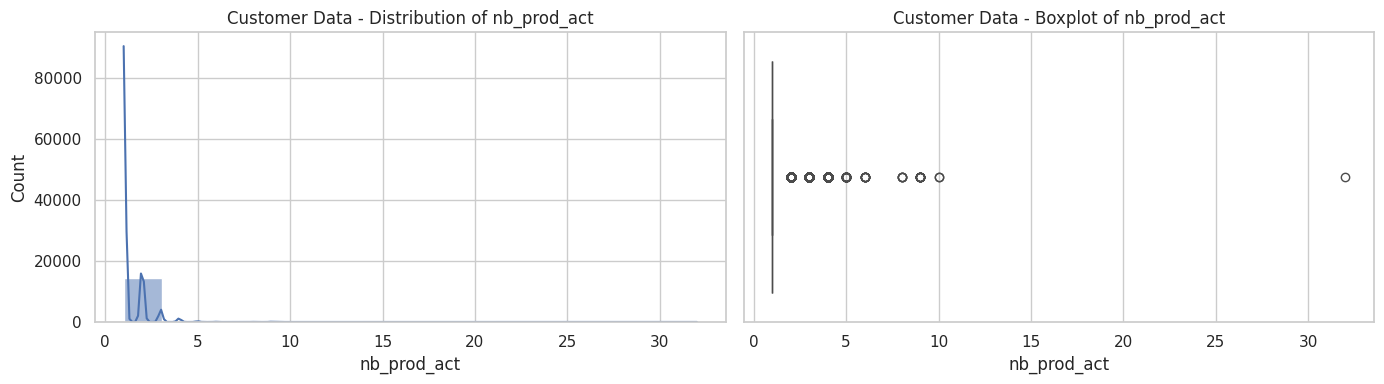

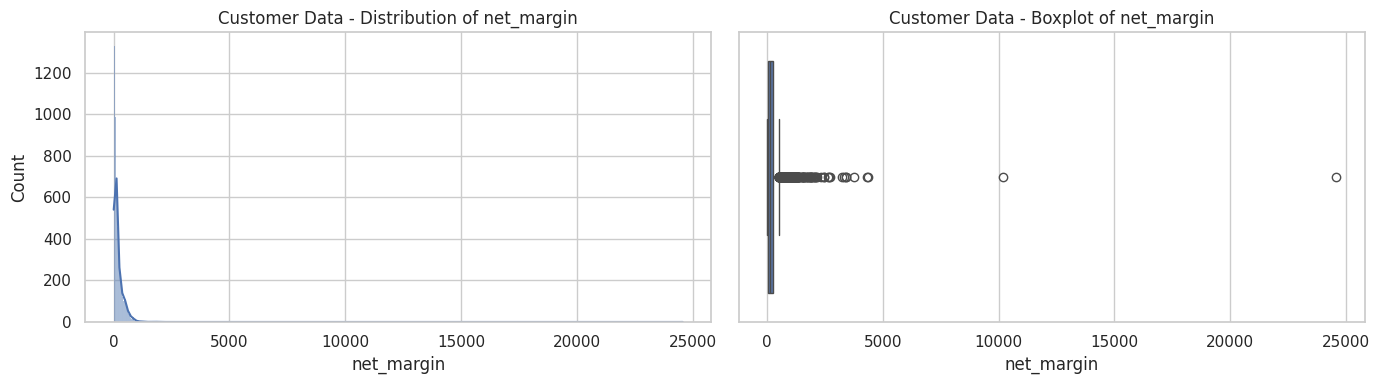

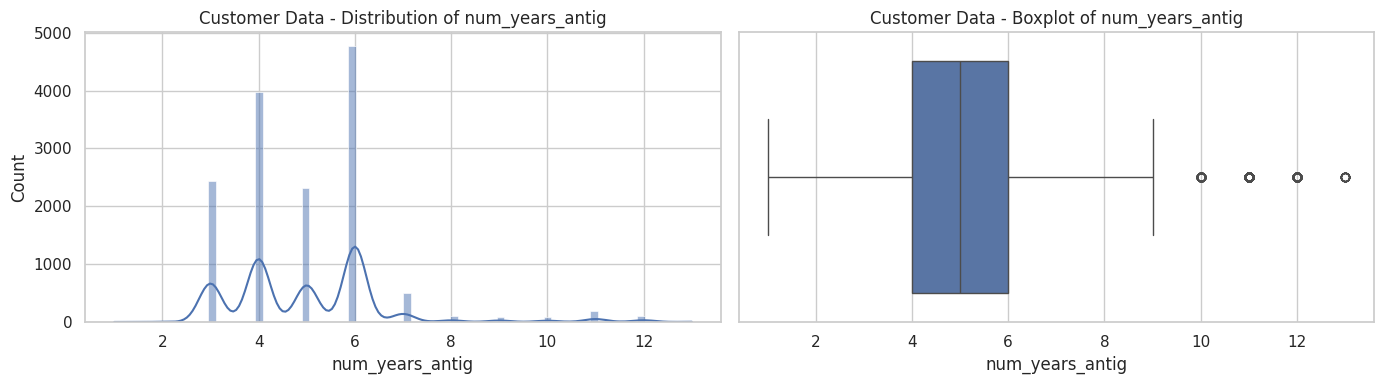

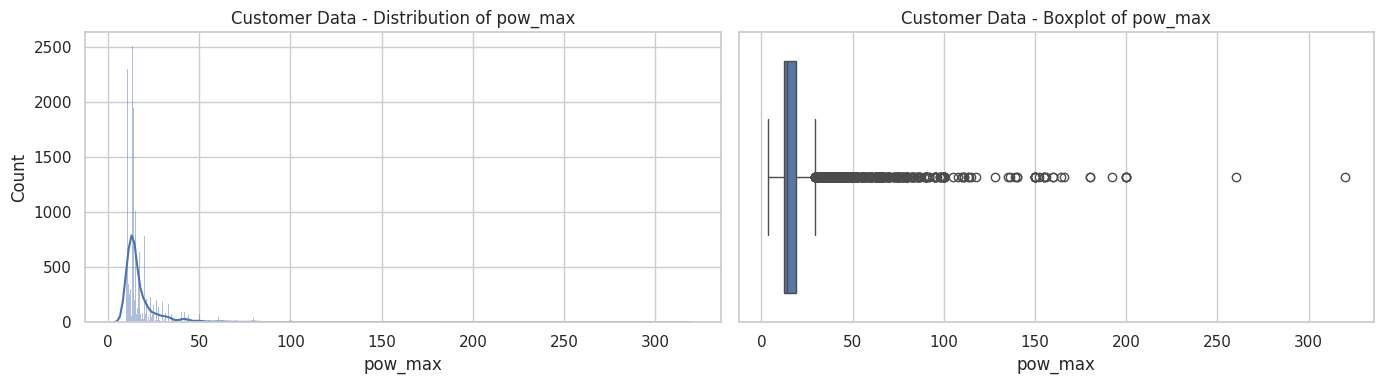

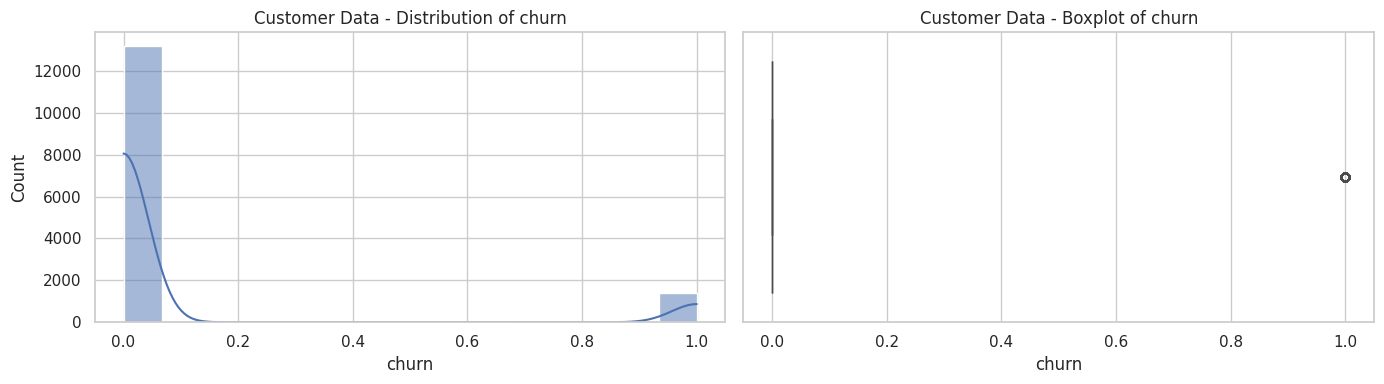

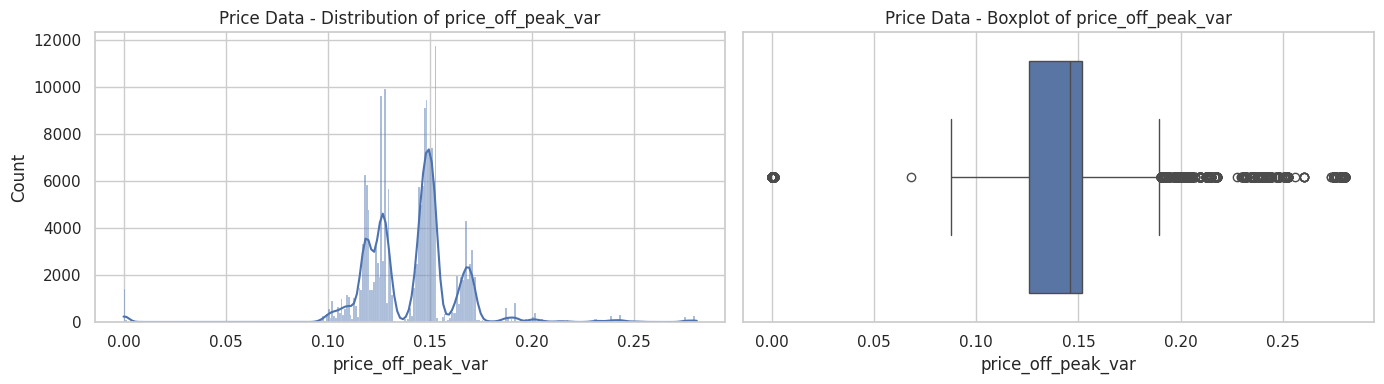

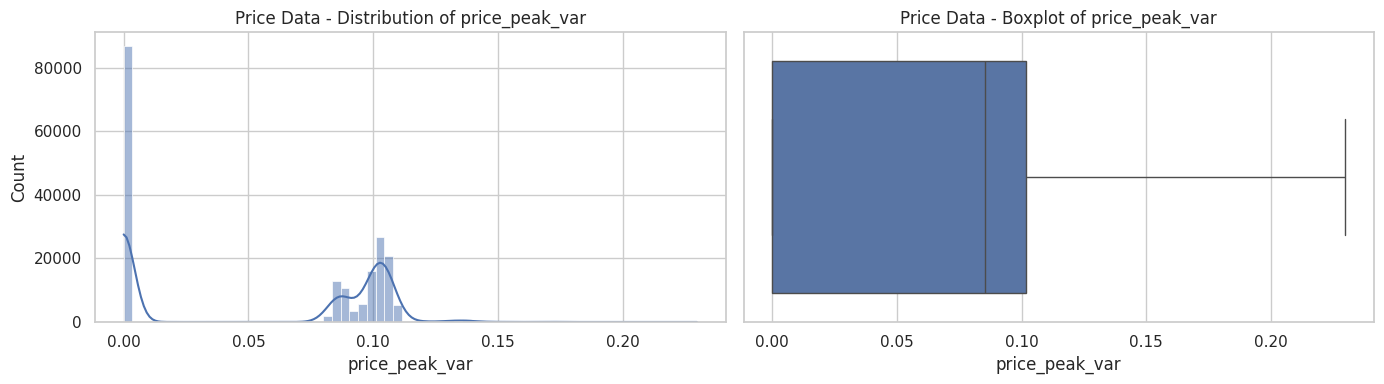

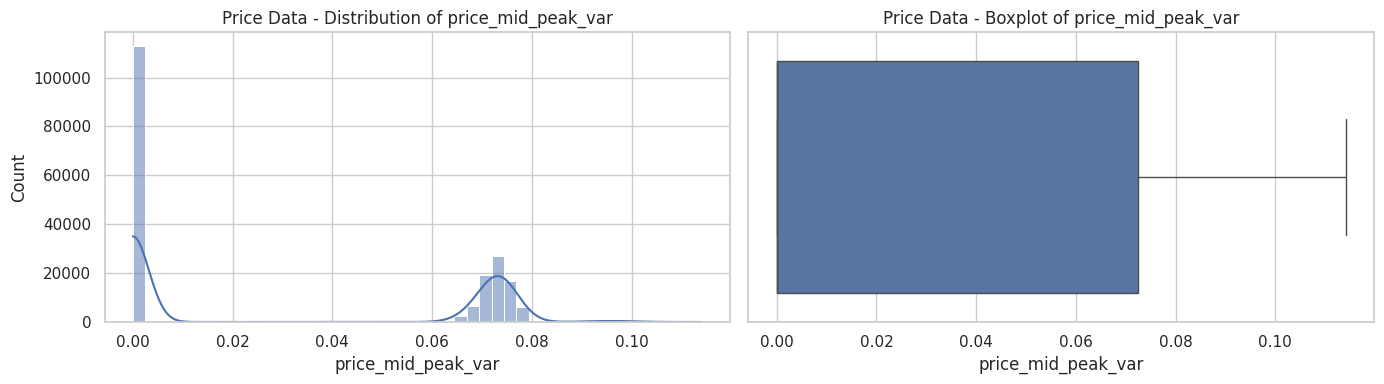

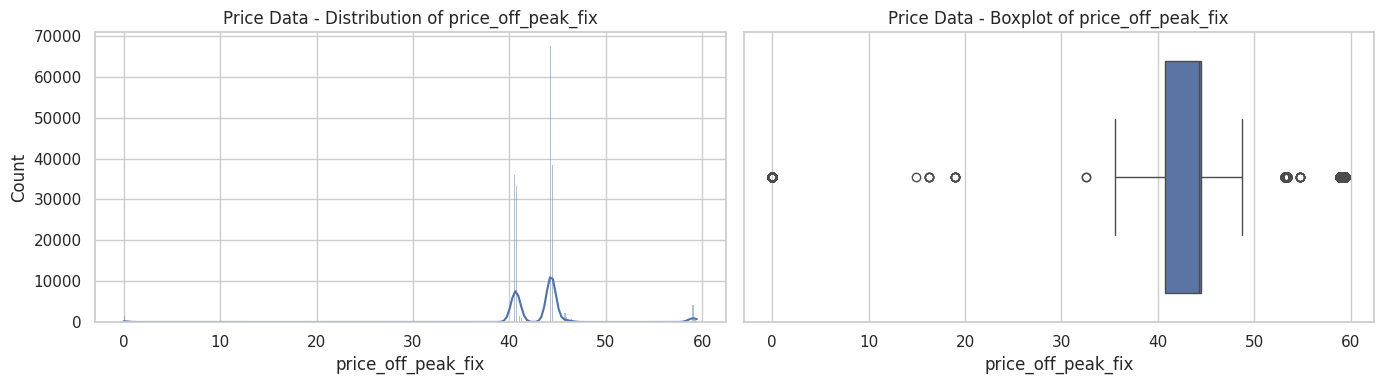

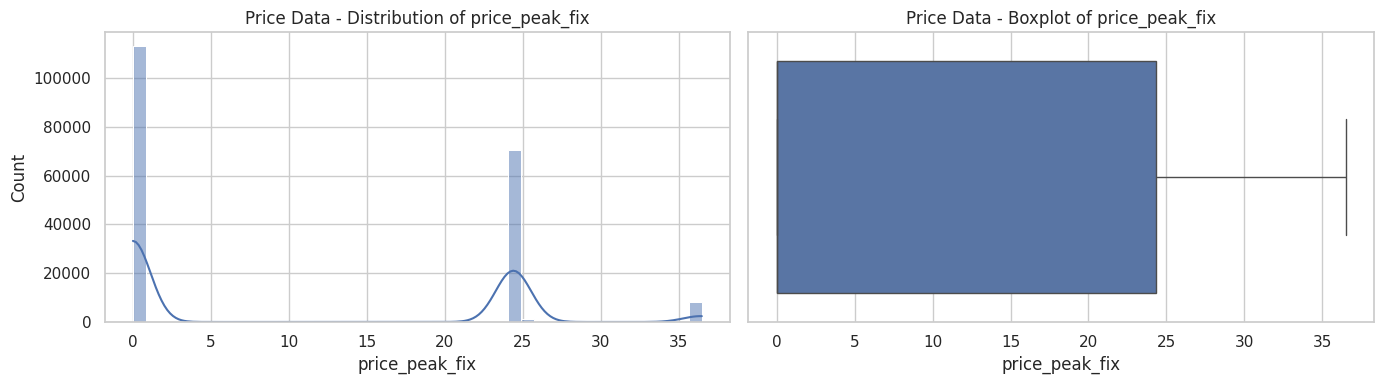

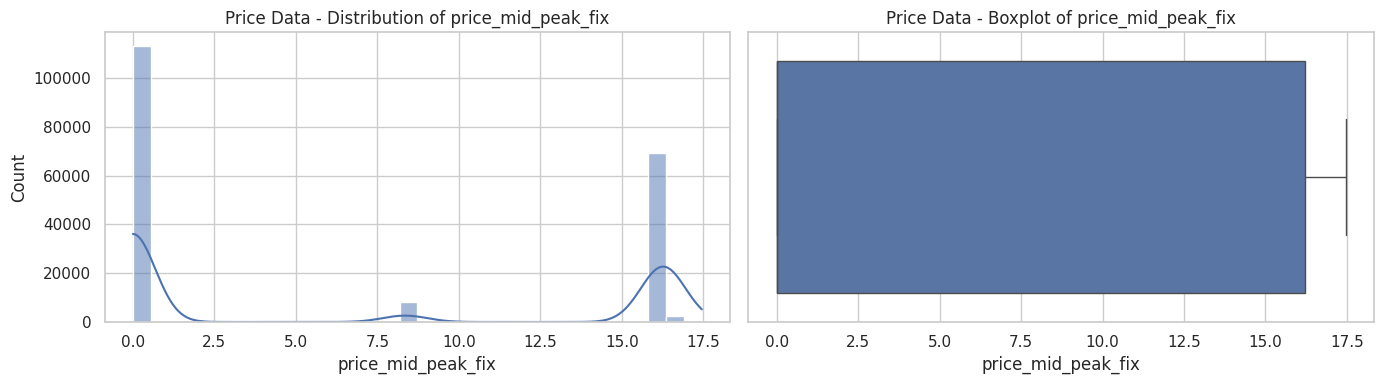

In [12]:

def plot_numeric_distributions(df, dataset_name):
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
        axes[0].set_title(f"{dataset_name} - Distribution of {col}")

        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"{dataset_name} - Boxplot of {col}")

        plt.tight_layout()
        plt.show()

plot_numeric_distributions(customer_df, "Customer Data")
plot_numeric_distributions(price_df, "Price Data")


# 10. Plot distributions for categorical columns

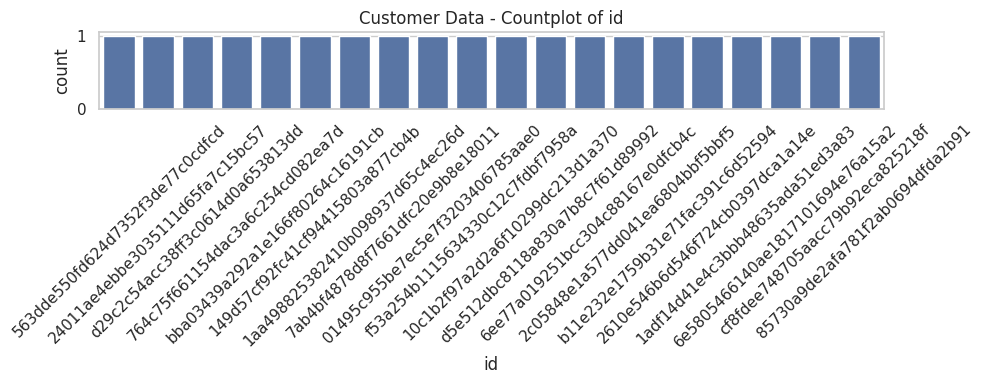

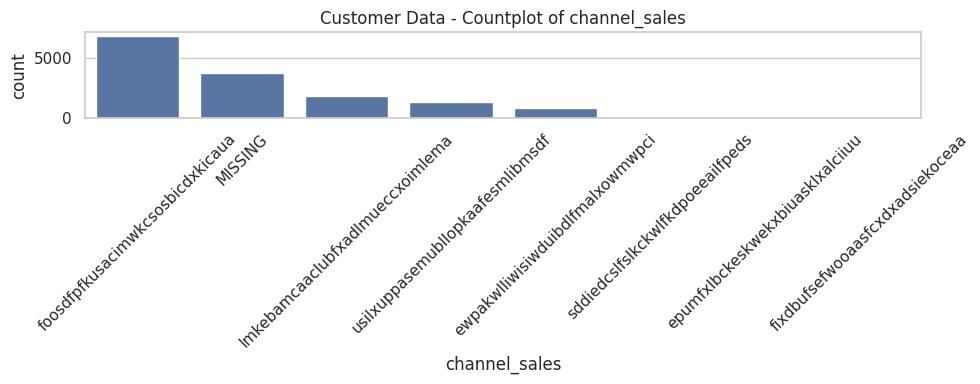

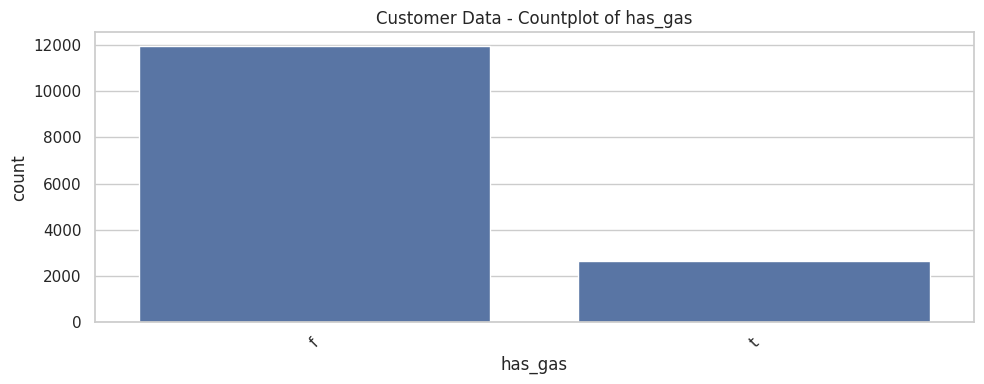

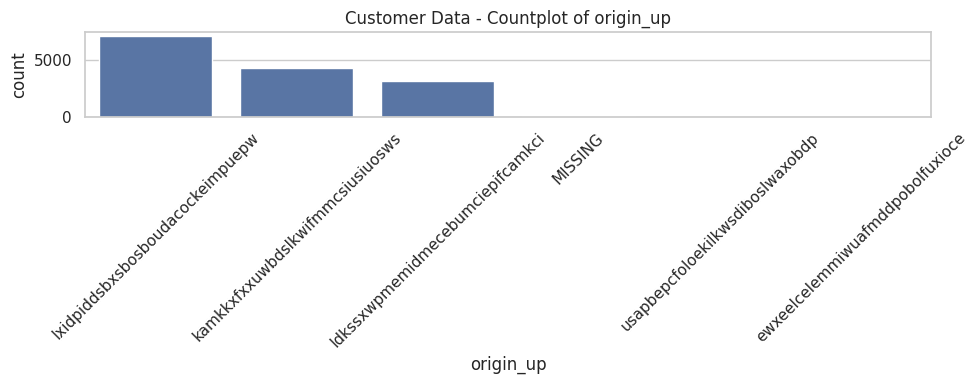

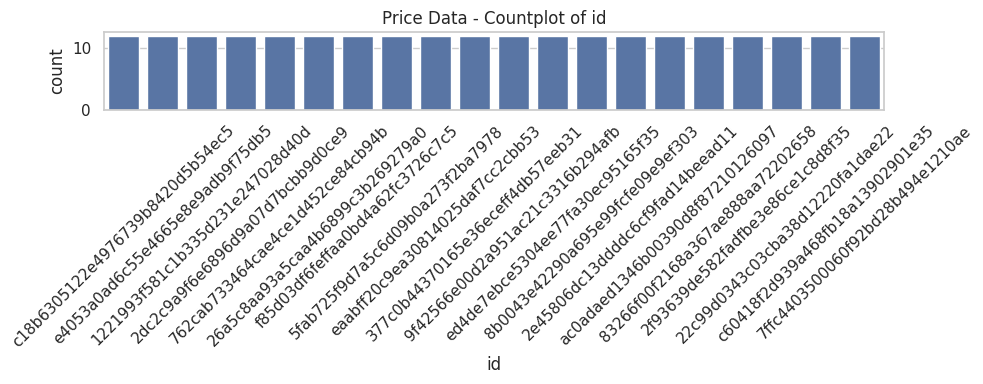

In [13]:

def plot_categorical_distributions(df, dataset_name, max_categories=20):
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

    for col in categorical_cols:
        plt.figure(figsize=(10, 4))
        order = df[col].value_counts().iloc[:max_categories].index
        sns.countplot(data=df, x=col, order=order)
        plt.title(f"{dataset_name} - Countplot of {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

plot_categorical_distributions(customer_df, "Customer Data")
plot_categorical_distributions(price_df, "Price Data")


# 11. Unique values per categorical column

In [14]:

def show_unique_values(df, name):
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    print(f"===== Unique values in {name} =====")
    for col in cat_cols:
        print(f"\nColumn: {col}")
        print(df[col].value_counts(dropna=False).head(20))

show_unique_values(customer_df, "Customer Data")
show_unique_values(price_df, "Price Data")


===== Unique values in Customer Data =====

Column: id
id
563dde550fd624d7352f3de77c0cdfcd    1
24011ae4ebbe3035111d65fa7c15bc57    1
d29c2c54acc38ff3c0614d0a653813dd    1
764c75f661154dac3a6c254cd082ea7d    1
bba03439a292a1e166f80264c16191cb    1
149d57cf92fc41cf94415803a877cb4b    1
1aa498825382410b098937d65c4ec26d    1
7ab4bf4878d8f7661dfc20e9b8e18011    1
01495c955be7ec5e7f3203406785aae0    1
f53a254b1115634330c12c7fdbf7958a    1
10c1b2f97a2d2a6f10299dc213d1a370    1
d5e512dbc8118a830a7b8c7f61d89992    1
6ee77a019251bcc304c88167e0dfcb4c    1
2c05848e1a577dd041ea6804bbf5bbf5    1
b11e232e1759b31e71fac391c6d52594    1
2610e546b6d546f724cb0397dca1a14e    1
1adf14d41e4c3bbb48635ada51ed3a83    1
6e5805466140ae1817101694e76a15a2    1
cf8fdee748705aacc79b92eca825218f    1
85730a9de2afa781f2ab0694dfda2b91    1
Name: count, dtype: int64

Column: channel_sales
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1

# 11. Churn distribution

### Churn exploration
Since the churn flag is already present in the client dataset, we compared feature distributions directly between churned and non-churned customers. This helps identify variables that may be predictive of churn.

Churn value counts:


,count
churn,
0,13187
1,1419


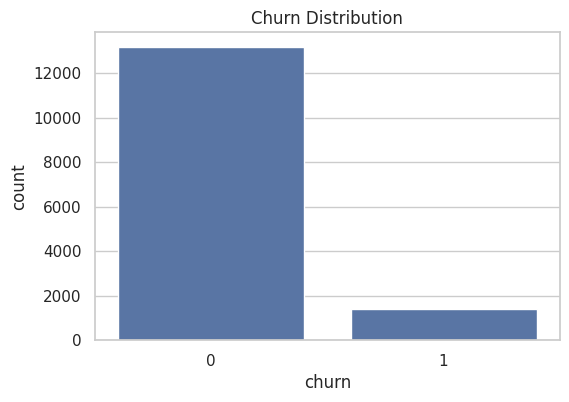

In [15]:

if "churn" in customer_df.columns:
    print("Churn value counts:")
    display(customer_df["churn"].value_counts(dropna=False))

    plt.figure(figsize=(6, 4))
    sns.countplot(data=customer_df, x="churn")
    plt.title("Churn Distribution")
    plt.show()
else:
    print("No 'churn' column found in client data.")

# 12. Numeric variables by churn

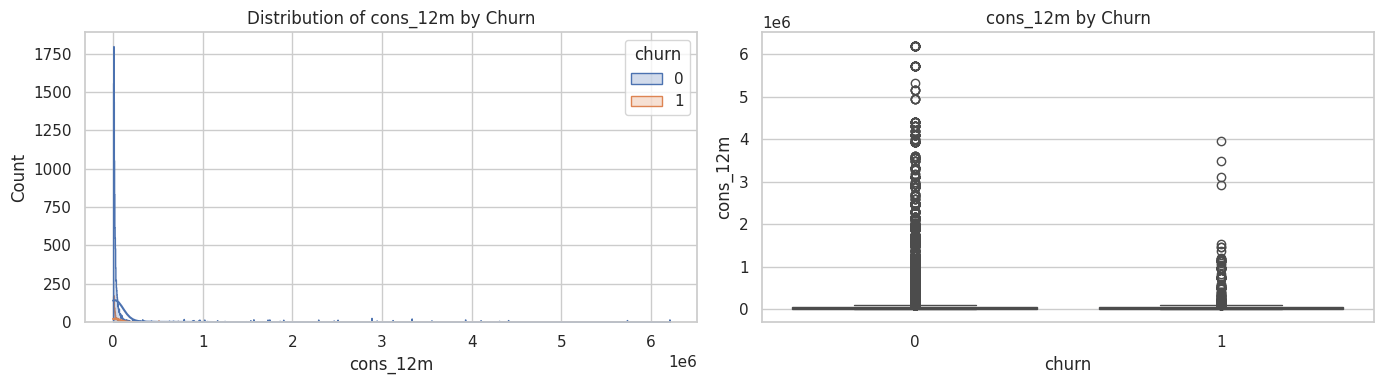

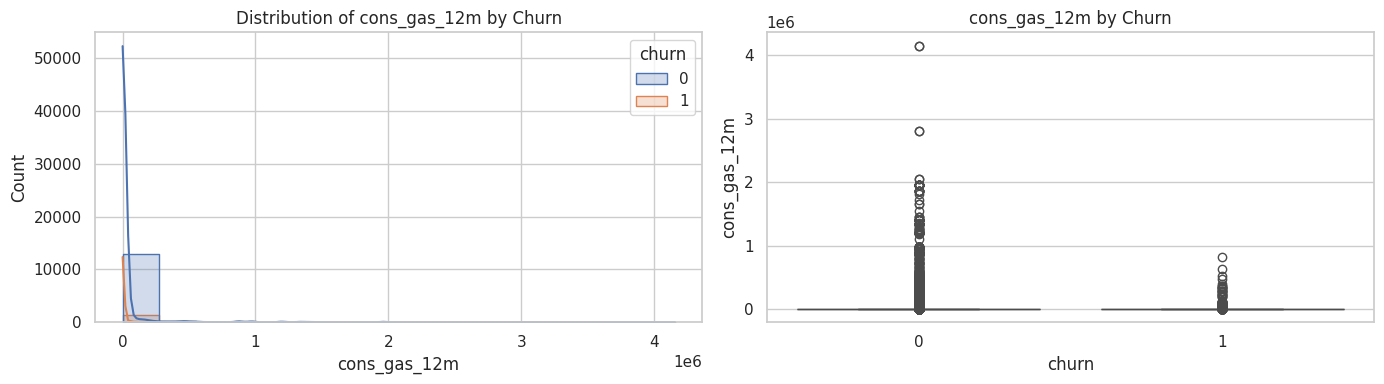

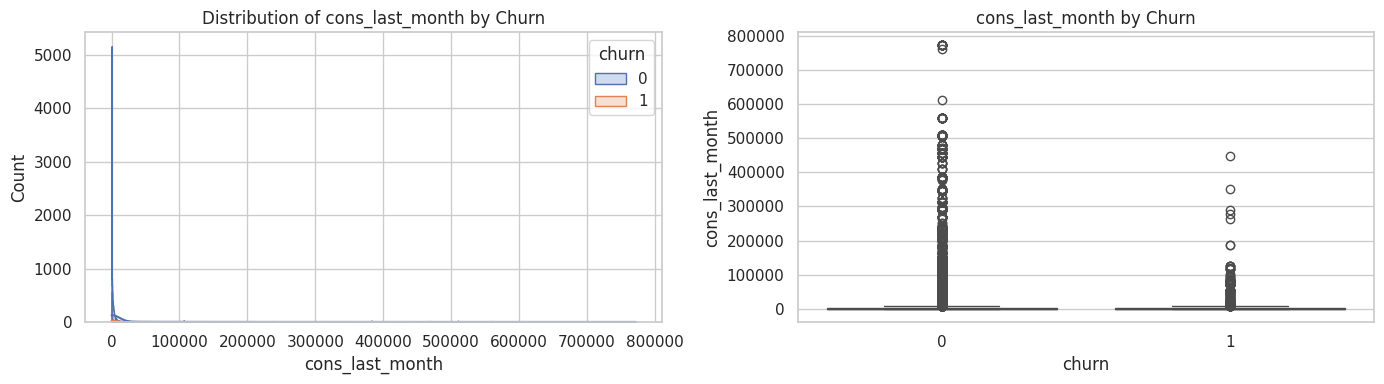

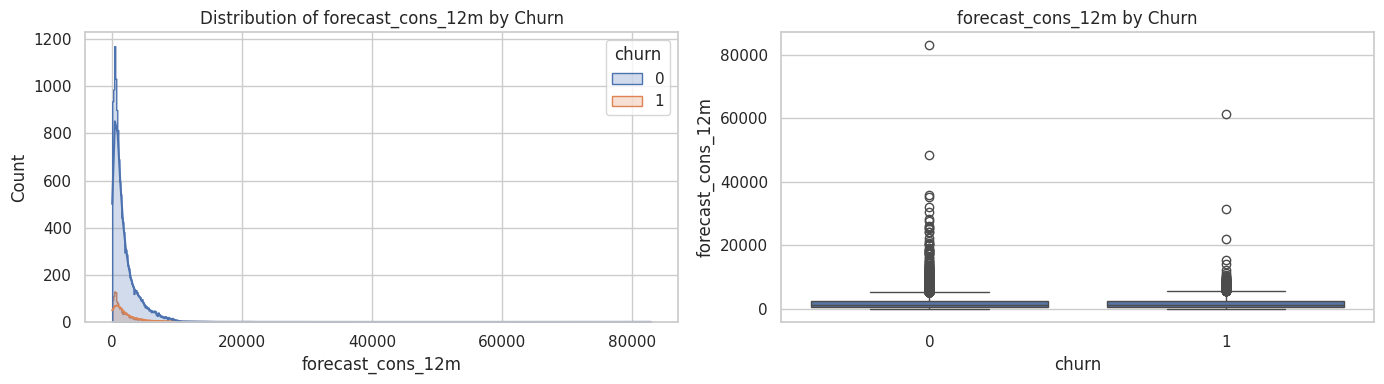

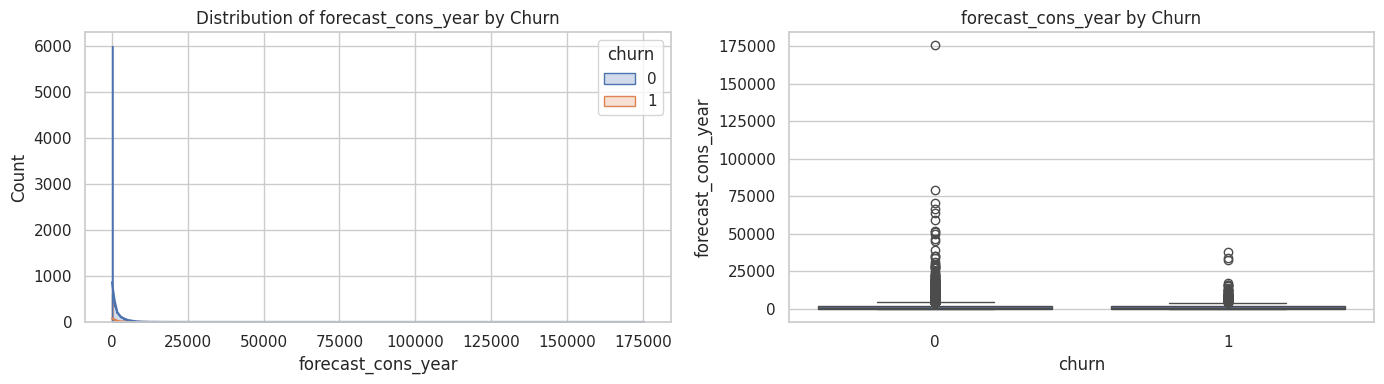

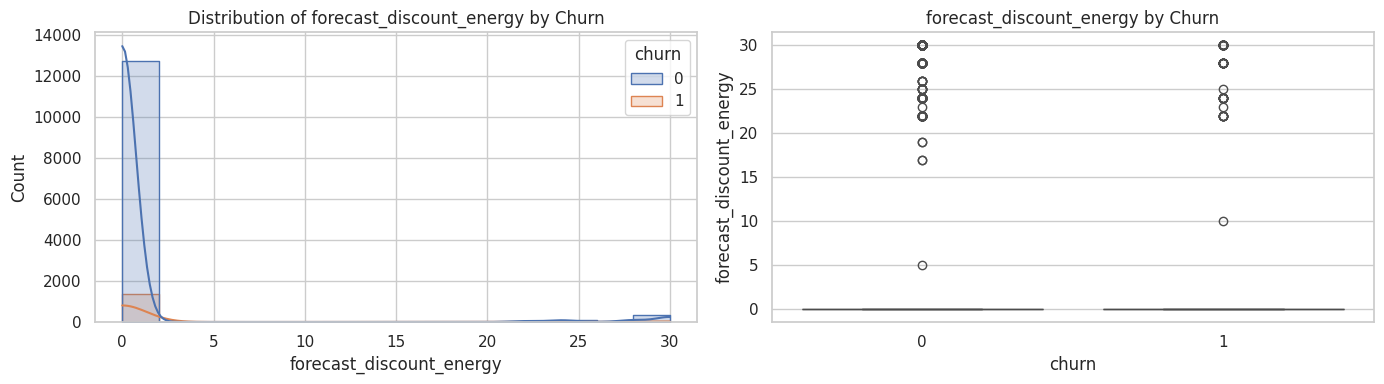

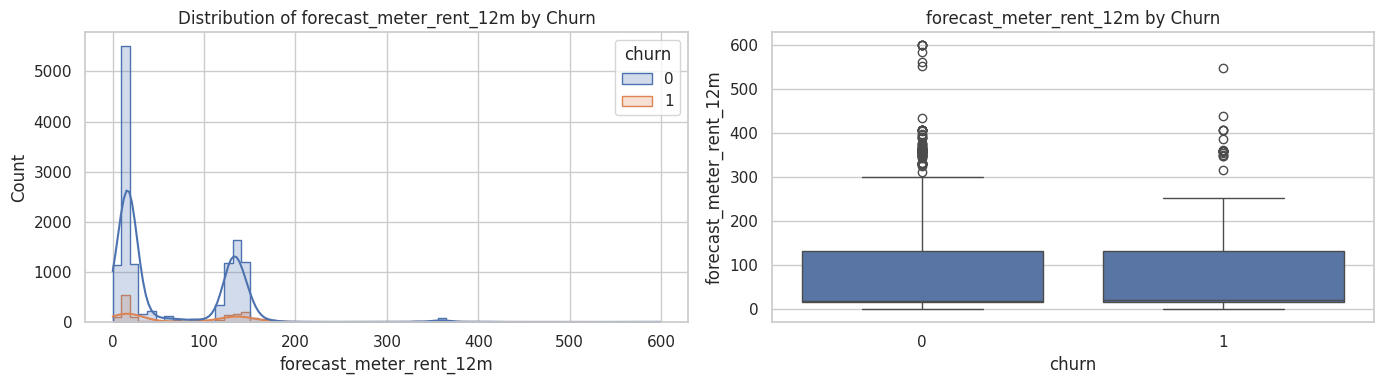

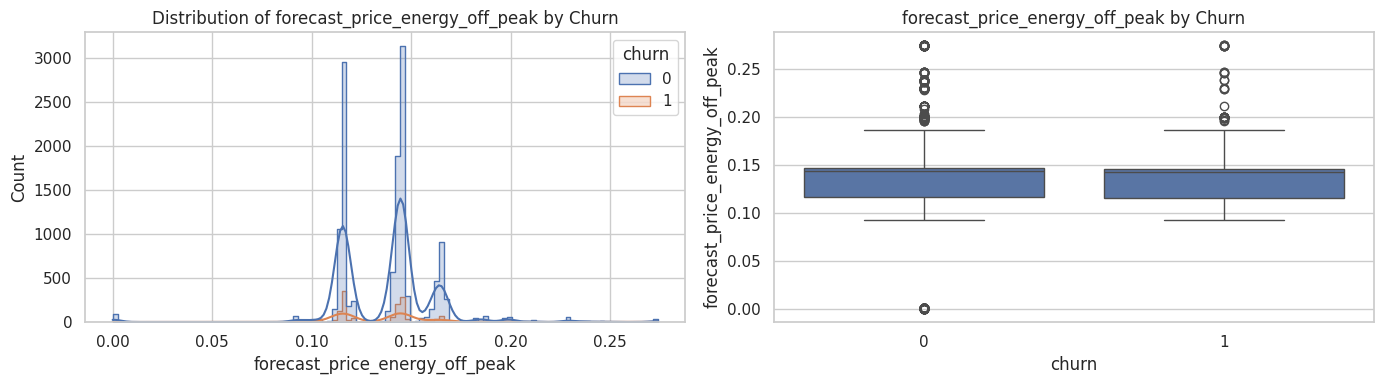

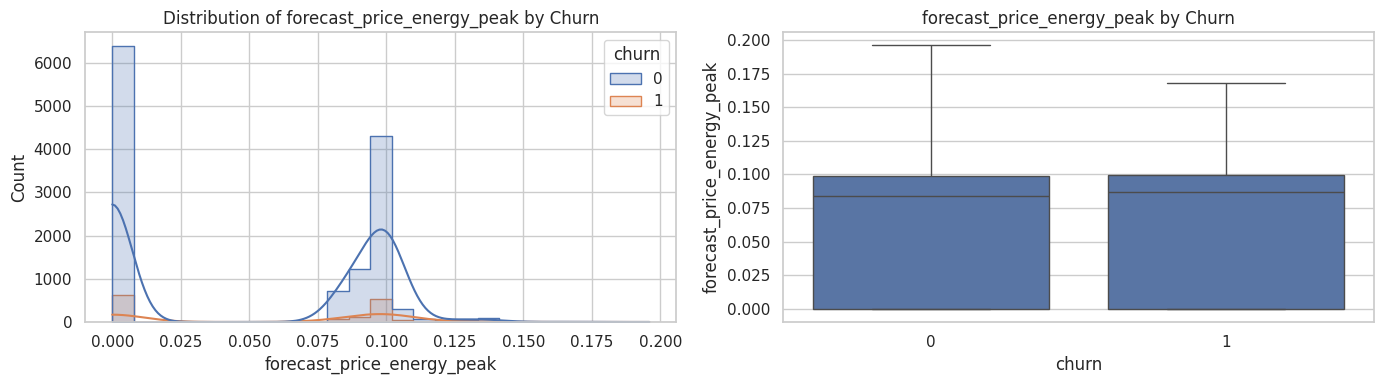

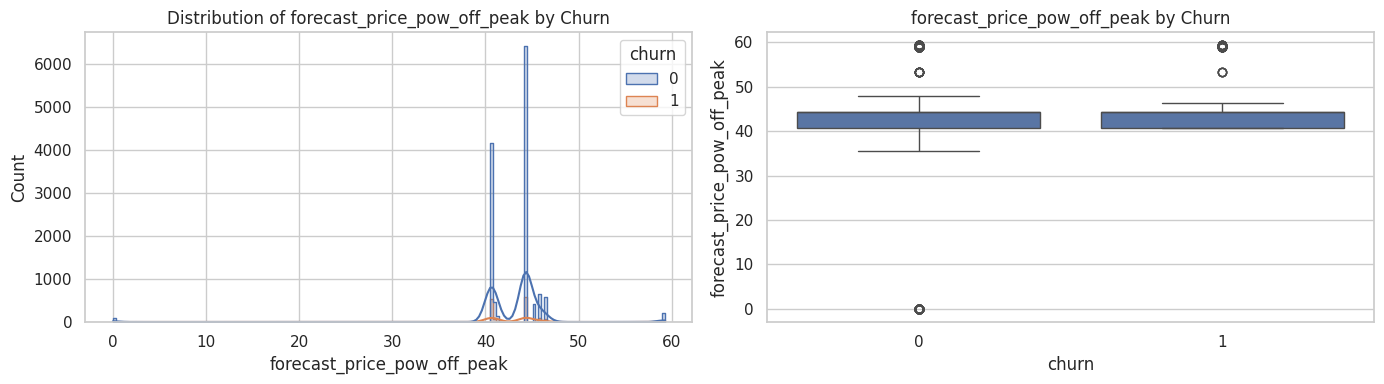

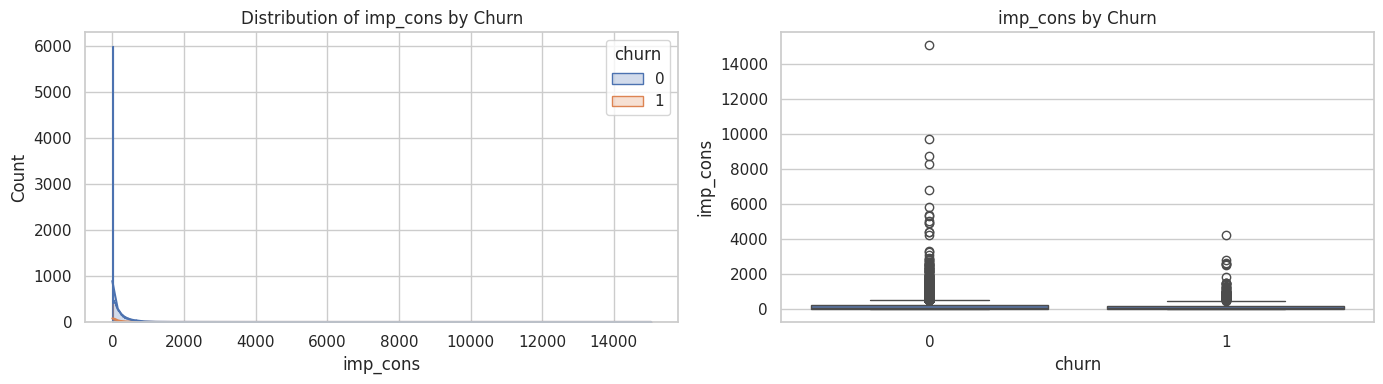

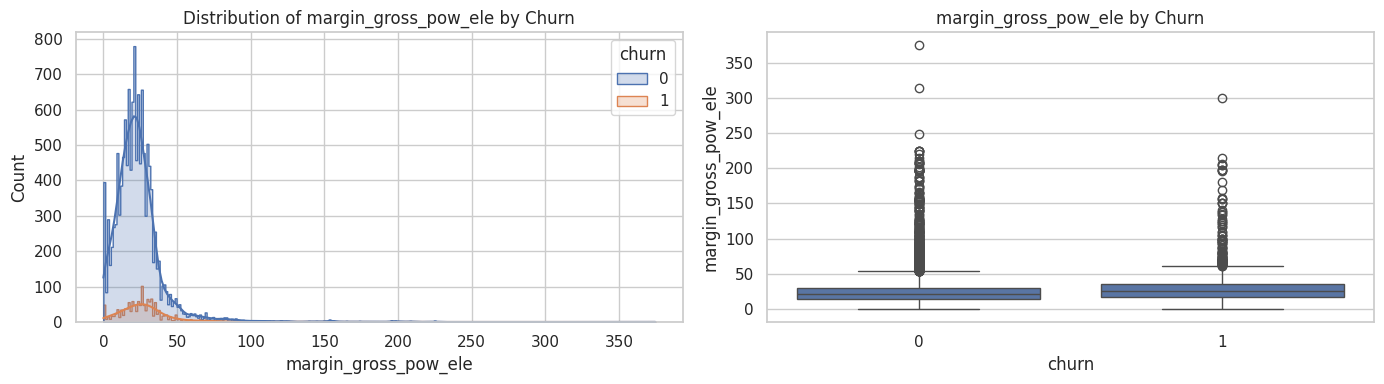

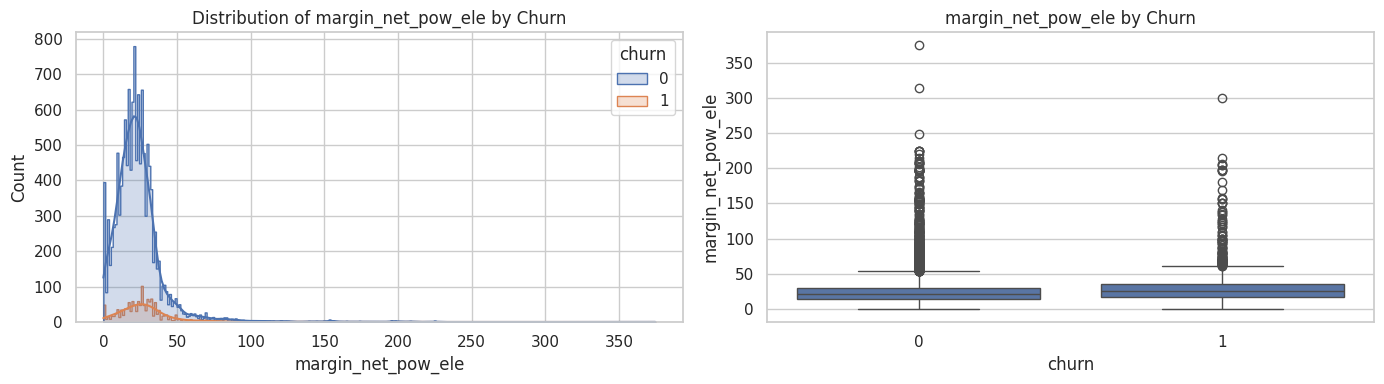

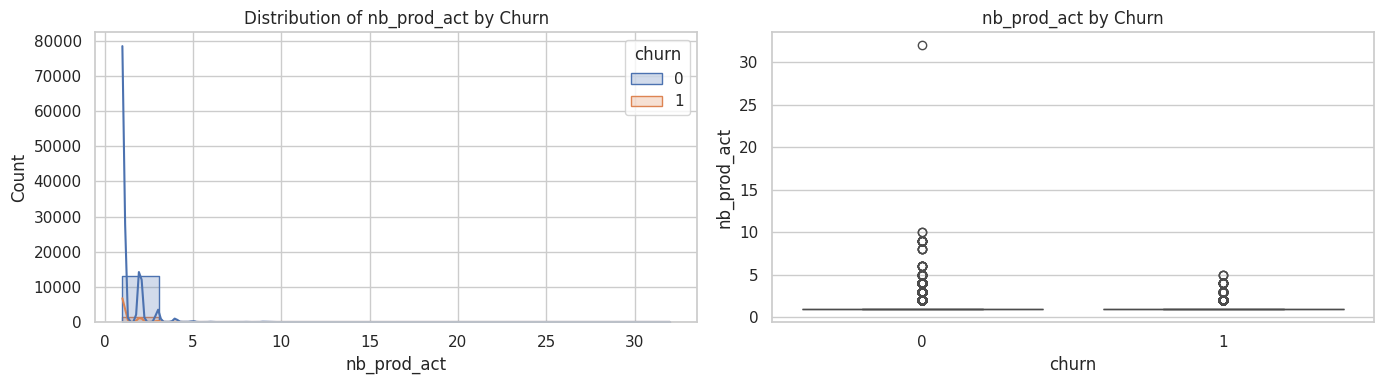

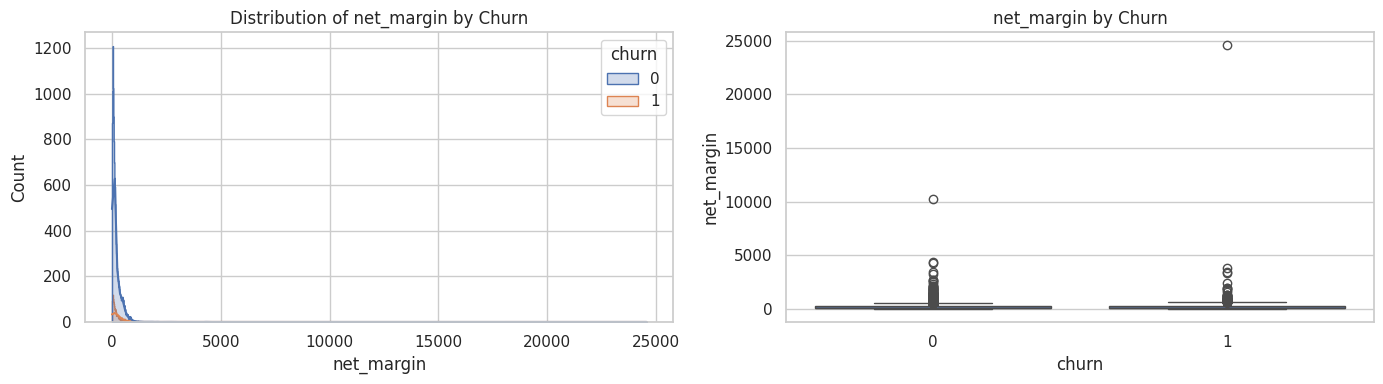

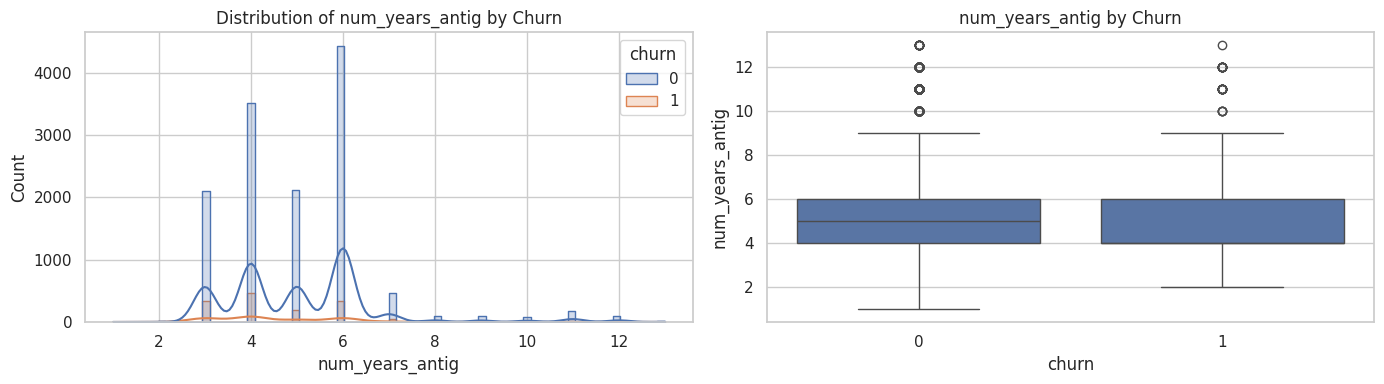

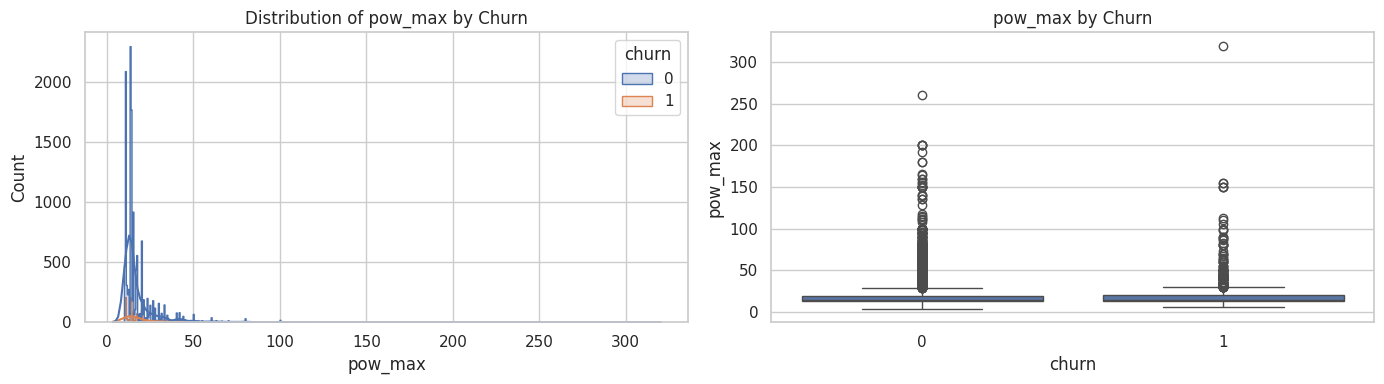

In [16]:

if "churn" in customer_df.columns:
    numeric_cols = customer_df.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != "churn"]

    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        sns.histplot(data=customer_df, x=col, hue="churn", kde=True, ax=axes[0], element="step")
        axes[0].set_title(f"Distribution of {col} by Churn")

        sns.boxplot(data=customer_df, x="churn", y=col, ax=axes[1])
        axes[1].set_title(f"{col} by Churn")

        plt.tight_layout()
        plt.show()

# 13. Categorical variables by churn

KeyboardInterrupt: 

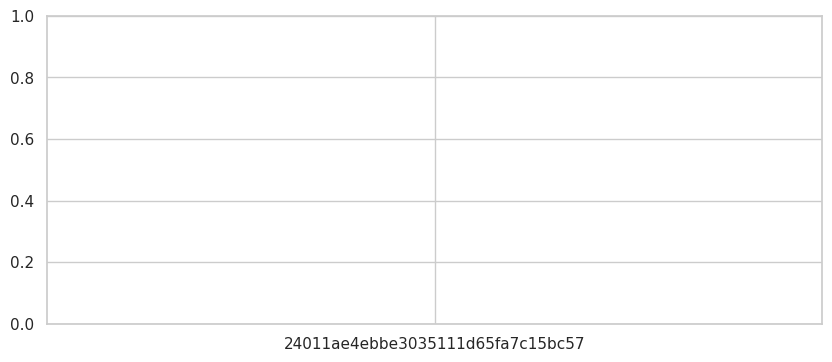

In [20]:

if "churn" in customer_df.columns:
    categorical_cols = customer_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    for col in categorical_cols:
        plt.figure(figsize=(10, 4))
        sns.countplot(data=customer_df, x=col, hue="churn")
        plt.title(f"{col} by Churn")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 14. Correlation heatmap

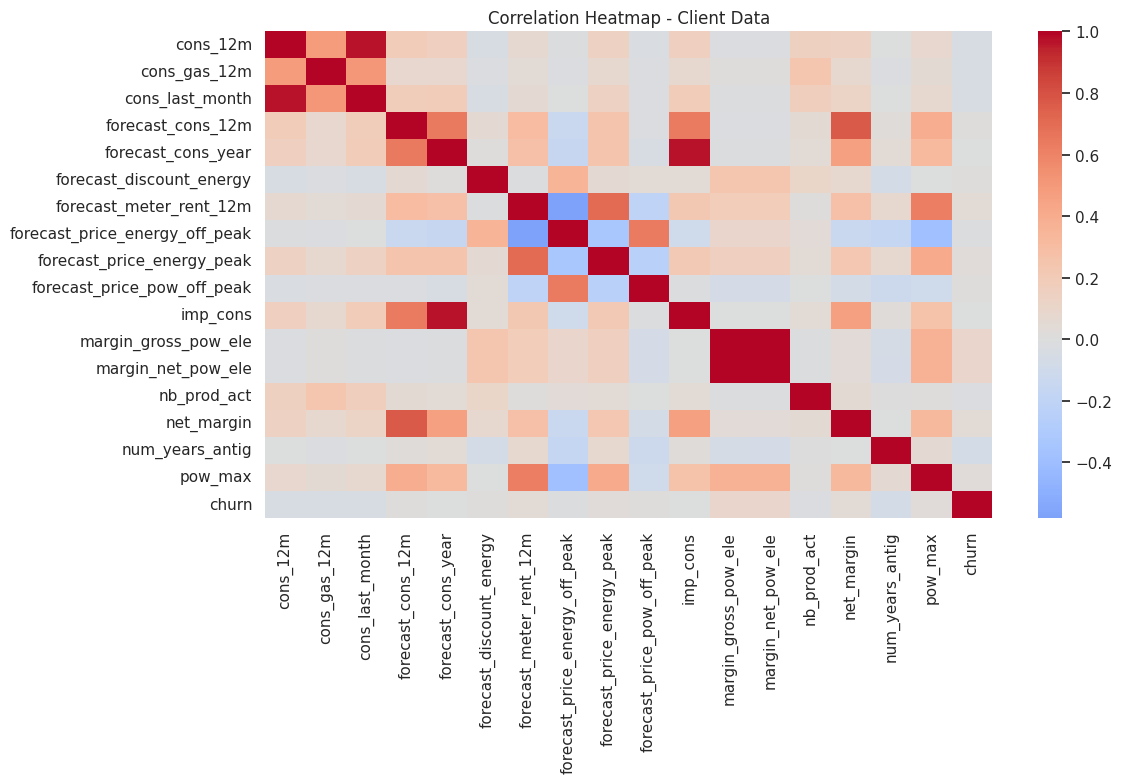

In [18]:

corr = customer_df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Client Data")
plt.tight_layout()
plt.show()

# 15. Price data summary by customer

In [21]:


if "id" in customer_df.columns and "id" in price_df.columns:
    price_summary = price_df.groupby("id").agg(
        mean_price_off_peak_var=("price_off_peak_var", "mean") if "price_off_peak_var" in price_df.columns else ("id", "count"),
        mean_price_peak_var=("price_peak_var", "mean") if "price_peak_var" in price_df.columns else ("id", "count"),
        mean_price_mid_peak_var=("price_mid_peak_var", "mean") if "price_mid_peak_var" in price_df.columns else ("id", "count"),
    ).reset_index()

    display(price_summary.head())
else:
    print("Skipping price aggregation because 'id' is not available in both datasets.")

,id,mean_price_off_peak_var,mean_price_peak_var,mean_price_mid_peak_var
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000


## 16. Key observations template

In [22]:


print("""
Points to comment on in the notebook:

1. What are the data types of each column?
2. Are there missing values or duplicates?
3. Is the churn variable balanced or imbalanced?
4. Which numeric variables differ between churned and retained customers?
5. Which categorical variables appear associated with churn?
6. Are any variables skewed or have strong outliers?
7. Does price data need aggregation before merging to the client level?
""")


Points to comment on in the notebook:

1. What are the data types of each column?
2. Are there missing values or duplicates?
3. Is the churn variable balanced or imbalanced?
4. Which numeric variables differ between churned and retained customers?
5. Which categorical variables appear associated with churn?
6. Are any variables skewed or have strong outliers?
7. Does price data need aggregation before merging to the client level?

